# GenCP VHR demo for Google Colab Environment (latest version Python 3.12.12)

This notebook demonstrates the process of generating synthetic GCP image chips from OSM raster maps created for VHR.

The test dataset, which belongs to SkySat satellite imagery, is located in the **"GenCP_VHR_demo/gencp_VHR_data_test/"** directory.

The VHR model trained using the TensorFlow library can be accessed through the following link:

HTML('<a href="https://mega.nz/file/eSpjWYaB#8UjUBgSG3hpSr0AlPWa1CRLaplwIzSaymOywkGATzss">Click here to access the VHR model</a>')

The model was trained using dataset-4, as specified in the study report.

The generated synthetic images were saved in the **"GenCP_VHR_demo/output/"** directory.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Installation

In [2]:
!pip install -r /content/drive/MyDrive/AI4QC/GenCP_VHR_demo/requirements.txt # If the file is compatible with Python 3.12 and the latest Colab, using it is unnecessary.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.1 MB/s eta 0:00:00


In [3]:
!python --version

Python 3.12.13


## Import Library

In [1]:
import os
import random
import re
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt


## Visualize OSM raster example

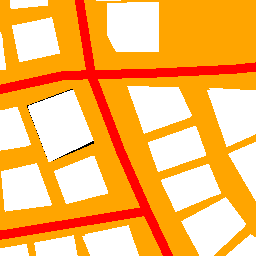

In [23]:
# path to test set
dataroot = "/content/drive/MyDrive/AI4QC/GenCP_VHR_demo/gencp_VHR_data_test/masks"

# show test data example
img_example = random.choice(os.listdir(dataroot))
img = Image.open(os.path.join(dataroot, img_example))
display(img)

## Generate images for all test samples

For the generation of images, both the images and masks need to be in a 3-band RGB format with 8-bit radiometric resolution.

In [32]:
!python /content/drive/MyDrive/AI4QC/GenCP_VHR_demo/test_VHR.py \
--model_path "/content/drive/MyDrive/AI4QC/GenCP_VHR_demo/VHR_model_weight/model_021888.h5" \
--img_files "/content/drive/MyDrive/AI4QC/GenCP_VHR_demo/gencp_VHR_data_test/images/*.tif" \
--masks_files "/content/drive/MyDrive/AI4QC/GenCP_VHR_demo/gencp_VHR_data_test/masks/*.tif" \
--output_folder "/content/drive/MyDrive/AI4QC/GenCP_VHR_demo/gencp_VHR_data_test/output/"

2026-05-16 08:43:03.032035: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-16 08:44:22.516003: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1778921062.517459    5909 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5

=== Model Summary ===
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 inpu

## Visualize generated images

Text(0.5, 1.0, 'Generated Image')

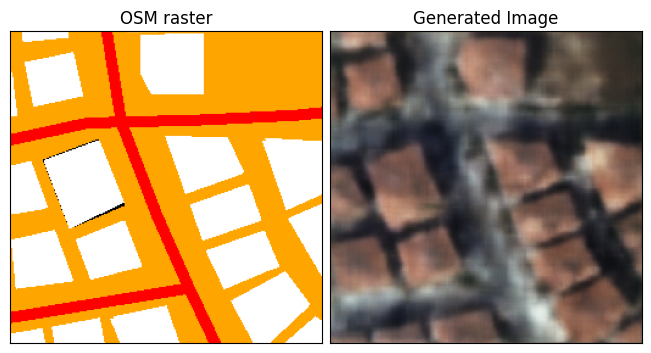

In [61]:
# path to test set
generated_dataroot = "/content/drive/MyDrive/AI4QC/GenCP_VHR_demo/gencp_VHR_data_test/output/"

# select random generated image

img_example = random.choice(os.listdir(generated_dataroot))
img_basename = img_example.replace("_preds.tif", "")
img_basename = img_basename.replace("_patch_", "_mask_") + ".tif"

osm_raster_path = os.path.join(dataroot, img_basename)
gen_img_path = os.path.join(generated_dataroot, img_example)


osm_img = Image.open(osm_raster_path)
gen_img = Image.open(gen_img_path)


%matplotlib inline

# display images
fig, ax = plt.subplots(1,2, constrained_layout=True)
for i in range(2):
    ax[i].xaxis.set_tick_params(labelbottom=False)
    ax[i].yaxis.set_tick_params(labelleft=False)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
ax[0].imshow(osm_img)
ax[0].set_title('OSM raster')
ax[1].imshow(gen_img)
ax[1].set_title('Generated Image')
